Name: Yash Gaikwad
Role Applied: Artificial Intelligence (AI) internship

In [1]:
# BITCOIN MARKET SENTIMENT ANALYSIS PROJECT

# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Graph Style
plt.style.use('ggplot')

In [2]:
# LOAD DATASETS
# =========================================================

print("\nLoading datasets...\n")

sentiment = pd.read_csv("fear_greed.csv")
trades = pd.read_csv("historical_data.csv")

print("Datasets loaded successfully!")


Loading datasets...

Datasets loaded successfully!


In [3]:
# DISPLAY DATA
# =========================================================

print("\n================ SENTIMENT DATASET ================\n")
print(sentiment.head())

print("\n================ TRADER DATASET ================\n")
print(trades.head())


================ SENTIMENT DATASET ================

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

================ TRADER DATASET ================

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    12

In [4]:
# COLUMN NAMES
# =========================================================

print("\n================ SENTIMENT COLUMNS ================\n")
print(sentiment.columns)

print("\n================ TRADER COLUMNS ================\n")
print(trades.columns)


================ SENTIMENT COLUMNS ================

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

================ TRADER COLUMNS ================

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [5]:
# CHECK MISSING VALUES
# =========================================================

print("\n================ MISSING VALUES ================\n")

print("\nSentiment Dataset Missing Values:\n")
print(sentiment.isnull().sum())

print("\nTrader Dataset Missing Values:\n")
print(trades.isnull().sum())


================ MISSING VALUES ================


Sentiment Dataset Missing Values:

timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Dataset Missing Values:

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [6]:
# DATA CLEANING
# =========================================================

print("\nCleaning datasets...\n")

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Convert trader timestamp
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

# Create matching date format
sentiment['date_only'] = sentiment['date'].dt.strftime('%Y-%m-%d')

trades['date_only'] = trades['Timestamp'].dt.strftime('%Y-%m-%d')

print("Date conversion completed!")


Cleaning datasets...

Date conversion completed!



================ SENTIMENT ANALYSIS ================

    timestamp  value classification       date   date_only
0  1517463000     30           Fear 2018-02-01  2018-02-01
1  1517549400     15   Extreme Fear 2018-02-02  2018-02-02
2  1517635800     40           Fear 2018-02-03  2018-02-03
3  1517722200     24   Extreme Fear 2018-02-04  2018-02-04
4  1517808600     11   Extreme Fear 2018-02-05  2018-02-05

Classification Counts:

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


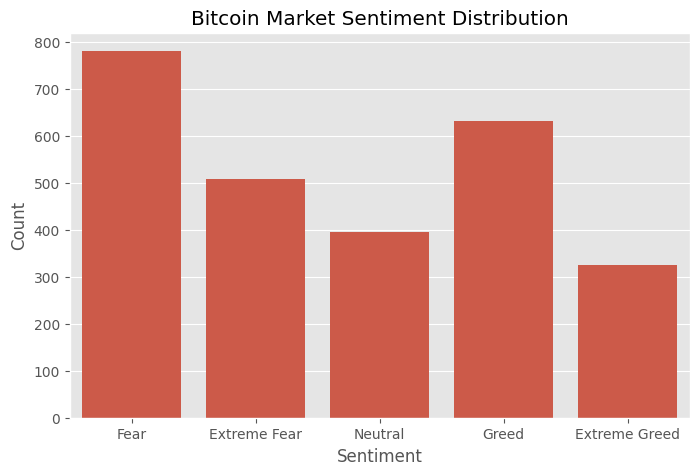

In [12]:
# SENTIMENT DATA ANALYSIS
# =========================================================

print("\n================ SENTIMENT ANALYSIS ================\n")

print(sentiment.head())

print("\nClassification Counts:\n")

print(sentiment['classification'].value_counts())

# Sentiment Distribution Graph

plt.figure(figsize=(8,5))

sns.countplot(
    x='classification',
    data=sentiment
)

plt.title('Bitcoin Market Sentiment Distribution')

plt.xlabel('Sentiment')

plt.ylabel('Count')

plt.show()

In [13]:
# TRADER DATA ANALYSIS
# =========================================================

print("\n================ TRADER ANALYSIS ================\n")

print(trades.head())


================ TRADER ANALYSIS ================

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Tran


Average Profit by Trade Side:

Side
BUY     36.104730
SELL    60.713803
Name: Closed PnL, dtype: float64


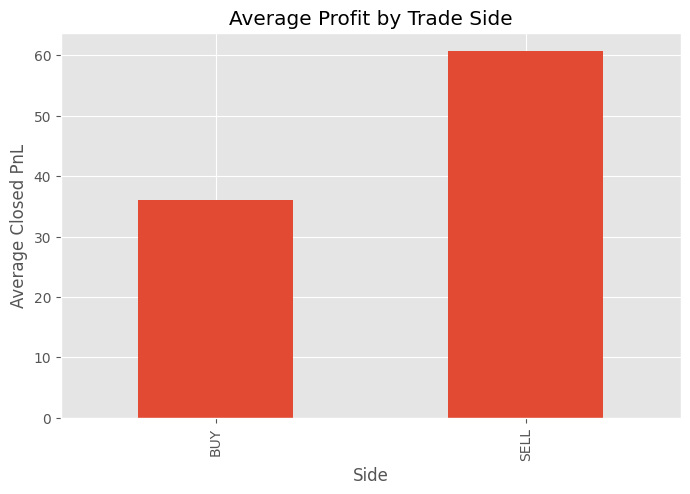

In [14]:
# AVERAGE PROFIT BY SIDE
# =========================================================

side_pnl = trades.groupby('Side')['Closed PnL'].mean()

print("\nAverage Profit by Trade Side:\n")

print(side_pnl)

plt.figure(figsize=(8,5))

side_pnl.plot(kind='bar')

plt.title('Average Profit by Trade Side')

plt.ylabel('Average Closed PnL')

plt.show()


Top 10 Profitable Coins:

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


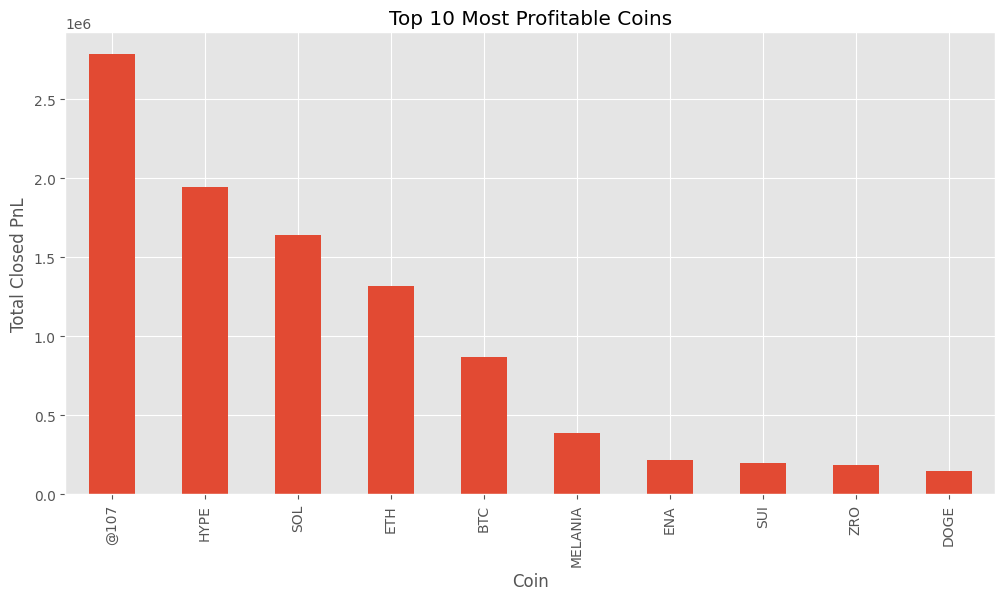

In [15]:
# TOP 10 MOST PROFITABLE COINS
# =========================================================

top_coins = trades.groupby('Coin')['Closed PnL'].sum()

top_coins = top_coins.sort_values(ascending=False).head(10)

print("\nTop 10 Profitable Coins:\n")

print(top_coins)

plt.figure(figsize=(12,6))

top_coins.plot(kind='bar')

plt.title('Top 10 Most Profitable Coins')

plt.ylabel('Total Closed PnL')

plt.show()

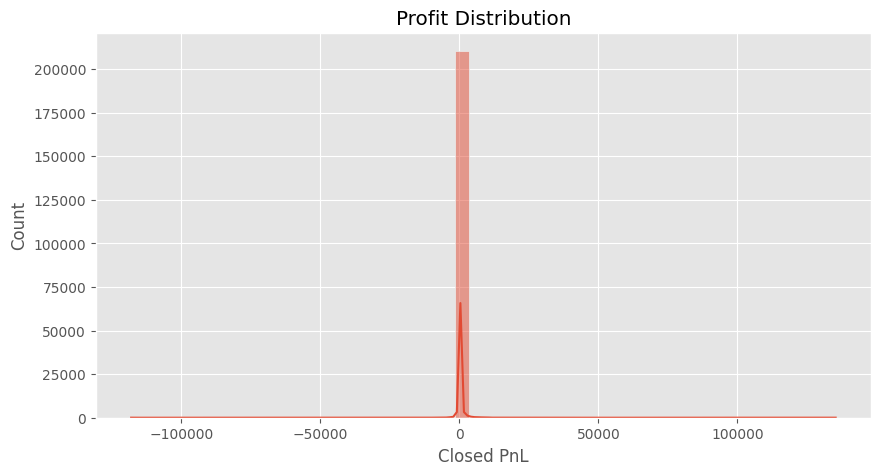

In [16]:
# PROFIT DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    trades['Closed PnL'],
    bins=50,
    kde=True
)

plt.title('Profit Distribution')

plt.xlabel('Closed PnL')

plt.show()

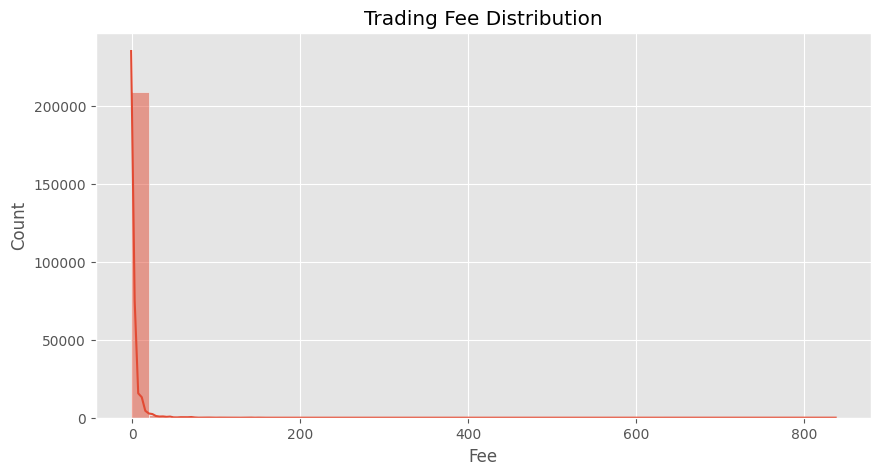

In [17]:
# FEES DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    trades['Fee'],
    bins=40,
    kde=True
)

plt.title('Trading Fee Distribution')

plt.xlabel('Fee')

plt.show()

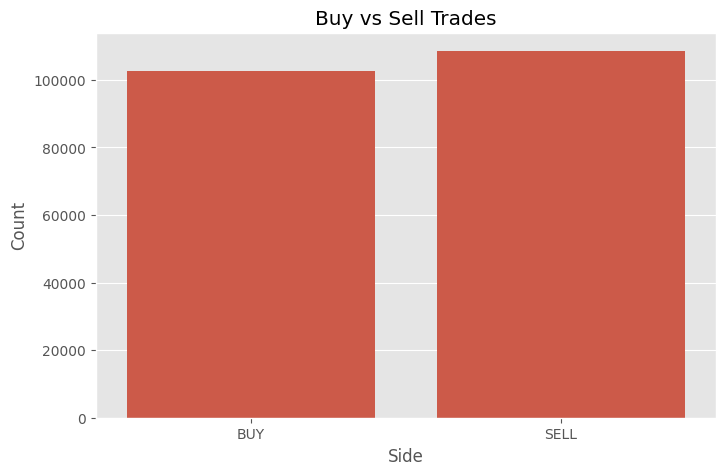

In [18]:
# BUY VS SELL COUNT
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Side',
    data=trades
)

plt.title('Buy vs Sell Trades')

plt.ylabel('Count')

plt.show()

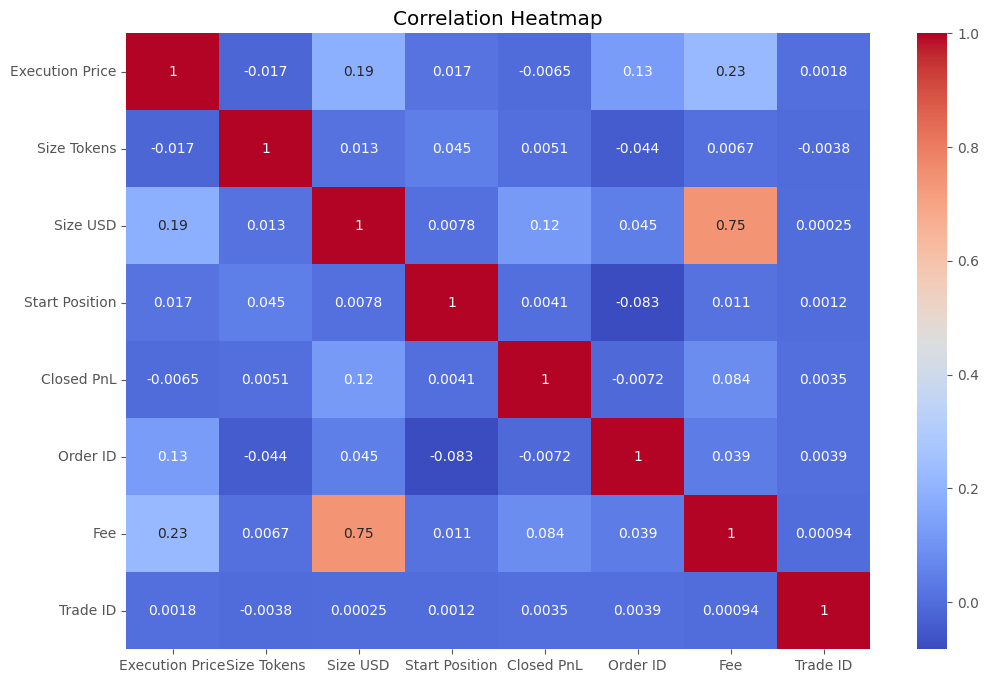

In [19]:
# CORRELATION HEATMAP
# =========================================================

numeric_cols = trades.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

## KEY INSIGHTS


1. Market sentiment data shows periods of Fear and Greed in Bitcoin markets.

2. Trader profitability varies significantly across different coins.

3. Some coins contribute most of the total trading profits.

4. Buy and Sell trades show different profit patterns.

5. Trading fees and position sizes influence overall profitability.

6. Trader activity patterns provide insights into crypto market behavior.

## CONCLUSION

This project analyzed Bitcoin market sentiment and historical trader activity.

The analysis explored trader profitability, coin performance,
trading activity, and market sentiment trends.

The findings help understand trading behavior and provide useful
insights for improving trading strategies and risk management
in cryptocurrency markets.